# EDA

- Baseline EDA work has already been done by CN, try not to overlap
- Exception: Provenance of numbers mentioned in EDA report
    - Double-check 
    - Nothing fancy, just basic counts/proportions/crosstabs
- Explore patients with multiple encounters
    - What are their numbers like?
    - Profile(s)?
- Explore "Low variance" filters
    - How to measure variance for categorical variables?
        - % of minority
        - % of majority
        - Entropy
        - Gini
- Explore age re-categorization by Strack _et al._
- Explore primary and secondary diagnoses

In [1]:
%%time

import os
import sys
from pprint import pp

import matplotlib
import matplotlib.pyplot as plt
import polars as pl
import scipy
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr

__VERSIONS: list[str] = [
    f"python={sys.version.split()[0]}",
    f"matplotlib={matplotlib.__version__}",
    f"polars={pl.__version__}",
    f"scipy={scipy.__version__}",
    f"seaborn={sns.__version__}",
]
__REQUIREMENTS_TXT: str = "\n".join(__VERSIONS)

PATH_TO_ROOT: str = "../.."
SOURCE: str = "data/diabetic_data.parquet"

del matplotlib
del scipy

sns.set_style("darkgrid")

print(__REQUIREMENTS_TXT, "\n")

python=3.13.7
matplotlib=3.10.6
polars=1.33.1
scipy=1.16.1
seaborn=0.13.2 

CPU times: total: 2.27 s
Wall time: 2.5 s


In [2]:
def get_data(source: str=SOURCE) -> pl.DataFrame | None:
    cwd = os.getcwd()
    try:
        os.chdir(PATH_TO_ROOT)
        if not os.path.isfile(source):
            from scripts.etl import etl
            df = etl.preprocess_raw()
            etl.make_parquet(df, dest=source)
        df = pl.read_parquet(source)
        return df
    finally:
        os.chdir(cwd)

In [3]:
df = get_data()
df

encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,diag_1b,diag_2b,diag_3b
i64,i64,str,str,enum,enum,str,str,str,i64,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,str,str,enum,str,str,str
2278392,8222157,"""Caucasian""","""Female""","""[0-10)""","""?""","""NULL""","""Not Mapped""","""Physician Referral""",1,"""?""","""Pediatrics-Endocrinology""",41,0,1,0,0,0,"""250.83""","""?""","""?""",1,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""NO""","""Diabetes mellitus""","""?""","""?"""
149190,55629189,"""Caucasian""","""Female""","""[10-20)""","""?""","""Emergency""","""Discharged to home""","""Emergency Room""",3,"""?""","""?""",59,0,18,0,0,0,"""276""","""250.01""","""255""",9,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Up""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""",""">30""","""Other Endocrine/Metabolic/Immu…","""Diabetes mellitus""","""Other Endocrine/Metabolic/Immu…"
64410,86047875,"""AfricanAmerican""","""Female""","""[20-30)""","""?""","""Emergency""","""Discharged to home""","""Emergency Room""",2,"""?""","""?""",11,5,13,2,0,1,"""648""","""250""","""V27""",6,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""NO""","""Pregnancy/Childbirth""","""Diabetes mellitus""","""Supplemental classification"""
500364,82442376,"""Caucasian""","""Male""","""[30-40)""","""?""","""Emergency""","""Discharged to home""","""Emergency Room""",2,"""?""","""?""",44,1,16,0,0,0,"""8""","""250.43""","""403""",7,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Up""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""","""NO""","""Infections""","""Diabetes mellitus""","""Circulatory"""
16680,42519267,"""Caucasian""","""Male""","""[40-50)""","""?""","""Emergency""","""Discharged to home""","""Emergency Room""",1,"""?""","""?""",51,0,8,0,0,0,"""197""","""157""","""250""",5,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""","""NO""","""Neoplasms""","""Neoplasms""","""Diabetes mellitus"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
443847548,100162476,"""AfricanAmerican""","""Male""","""[70-80)""","""?""","""Emergency""","""Discharged/transferred to SNF""","""Emergency Room""",3,"""MC""","""?""",51,0,16,0,0,0,"""250.13""","""291""","""458""",9,"""None""",""">8""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""

---

## Proportions

In [4]:
def _cs(df: pl.DataFrame, c1: str="proportion", c2: str="cumulative") -> pl.DataFrame:
    return df.with_columns(pl.cum_sum(c1).alias(c2))

def props(df: pl.DataFrame, name: str) -> pl.DataFrame:
    return df[name].value_counts(normalize=True).sort(name).pipe(_cs)

def _gini_series(s: pl.Series) -> float:
    return 1 - s.value_counts(normalize=True).with_columns(pl.col("proportion").pow(2))["proportion"].sum()

def _gini(df: pl.DataFrame, cols: list[str]) -> pl.DataFrame:
    res = pl.DataFrame({
        "variable": cols,
        "gini": [_gini_series(s) for s in df.select(cols)],
    })
    return res

### Some drug (combinations) are uninformative

- 23 variables
    - Values: "No", "Down", "Steady", "Up"
        - Ordinal in terms of relative amount administered
    - 18 single drugs, 5 pairs
    - 2 completely uninformative

In [5]:
drugs = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
         'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
         'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
         'examide', 'citoglipton', 'insulin',
         'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
# 23: 18 singles, 5 pairs.

with pl.Config(tbl_rows=-1) as cfg:
    (df
        .select(drugs)
        .unpivot()
        .group_by("variable", "value")
        .len()
        .pivot("value", index="variable")
        .with_columns(pl.max_horizontal(pl.exclude("variable")).truediv(pl.sum_horizontal(pl.exclude("variable"))).alias("pct_mode"))
        .join(_gini(df, drugs), on="variable", how="left")
        .sort("pct_mode", descending=True)
        .pipe(display)
    )

variable,Steady,No,Up,Down,pct_mode,gini
str,u32,u32,u32,u32,f64,f64
"""citoglipton""",null,101766,null,null,1.0,0.0
"""examide""",null,101766,null,null,1.0,0.0
"""metformin-pioglitazone""",1,101765,null,null,0.99999,0.00002
"""glimepiride-pioglitazone""",1,101765,null,null,0.99999,0.00002
"""acetohexamide""",1,101765,null,null,0.99999,0.00002
"""metformin-rosiglitazone""",2,101764,null,null,0.99998,0.000039
"""troglitazone""",3,101763,null,null,0.999971,0.000059
"""glipizide-metformin""",13,101753,null,null,0.999872,0.000255
"""tolbutamide""",23,101743,null,null,0.999774,0.000452


### Age

In [6]:
props(df, "age")

age,proportion,cumulative
enum,f64,f64
"""[0-10)""",0.001582,0.001582
"""[10-20)""",0.00679,0.008372
"""[20-30)""",0.016282,0.024655
"""[30-40)""",0.037095,0.06175
"""[40-50)""",0.095169,0.156919
"""[50-60)""",0.169565,0.326484
"""[60-70)""",0.220928,0.547413
"""[70-80)""",0.256156,0.803569
"""[80-90)""",0.168986,0.972555


### Skewness

- `time_in_hospital`
- `num_lab_procedures`
- `num_medications`

In [7]:
df["time_in_hospital"].skew()

1.133982004467975

In [8]:
df["num_lab_procedures"].skew()

-0.23654043395051044

In [9]:
df["num_medications"].skew()

1.3266525795561779

### Primary and secondary diagnoses

In [10]:
df["diag_1"].value_counts(normalize=True, sort=True).pipe(_cs).head()

diag_1,proportion,cumulative
str,f64,f64
"""428""",0.067429,0.067429
"""414""",0.064668,0.132097
"""786""",0.039463,0.17156
"""410""",0.035513,0.207073
"""486""",0.034471,0.241544


In [11]:
df["diag_1b"].value_counts(normalize=True, sort=True).filter(pl.col("diag_1b").str.contains("Diabetes|Metabolic")).pipe(_cs)

diag_1b,proportion,cumulative
str,f64,f64
"""Diabetes mellitus""",0.08605,0.08605
"""Other Endocrine/Metabolic/Immu…",0.026551,0.112601


In [12]:
df["diag_2b"].value_counts(normalize=True, sort=True).pipe(_cs).head()

diag_2b,proportion,cumulative
str,f64,f64
"""Circulatory""",0.308207,0.308207
"""Diabetes mellitus""",0.12572,0.433927
"""Respiratory""",0.100731,0.534658
"""Other Endocrine/Metabolic/Immu…",0.080803,0.615461
"""Genitourinary""",0.078484,0.693945


In [13]:
df["diag_2b"].value_counts(normalize=True, sort=True).filter(pl.col("diag_2b").str.contains("Diabetes|Metabolic")).pipe(_cs)

diag_2b,proportion,cumulative
str,f64,f64
"""Diabetes mellitus""",0.12572,0.12572
"""Other Endocrine/Metabolic/Immu…",0.080803,0.206523


In [14]:
df["diag_3b"].value_counts(normalize=True, sort=True).pipe(_cs).head()

diag_3b,proportion,cumulative
str,f64,f64
"""Circulatory""",0.293988,0.293988
"""Diabetes mellitus""",0.168593,0.462581
"""Other Endocrine/Metabolic/Immu…",0.089922,0.552503
"""Respiratory""",0.066564,0.619067
"""Genitourinary""",0.062172,0.681239


In [15]:
df["diag_3b"].value_counts(normalize=True, sort=True).filter(pl.col("diag_3b").str.contains("Diabetes|Metabolic")).pipe(_cs)

diag_3b,proportion,cumulative
str,f64,f64
"""Diabetes mellitus""",0.168593,0.168593
"""Other Endocrine/Metabolic/Immu…",0.089922,0.258515


## Cross-tabulations

In [16]:
def recalc_props(df: pl.DataFrame) -> pl.DataFrame:
    col_ex = pl.exclude(df.columns[0])
    df2 = df.select(pl.exclude("^.*_prop$"))
    cols = df2.select(col_ex).columns
    for k in cols:
        df2 = df2.with_columns(pl.col(k).truediv(pl.sum_horizontal(col_ex)).alias(f"{k}_prop"))
    return df2

def combine_readmit(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns(pl.col(">30").add(pl.col("<30")).alias("YES")).drop(">30", "<30")

def xtab2(df: pl.DataFrame, y: str, x: str="readmitted") -> pl.DataFrame:
    return df.group_by(y, x).len().sort(y, x).pivot(on=x, index=y).pipe(recalc_props)

### Age <70 vs >=70

In [17]:
xtab2(df, "age").with_columns(pl.col("age").ge("[70-80)").alias("ge70yo")).drop("age").group_by("ge70yo").sum().pipe(recalc_props)

ge70yo,NO,>30,<30,NO_prop,>30_prop,<30_prop
bool,u32,u32,u32,f64,f64,f64
false,30769,19039,5900,0.552326,0.341761,0.105908
true,24095,16506,5457,0.523145,0.35837,0.118479


### Race

In [18]:
xtab2(df, "race").pipe(combine_readmit).pipe(recalc_props).sort("YES_prop", descending=True)

race,NO,YES,NO_prop,YES_prop
str,u32,u32,f64,f64
"""Caucasian""",40383,35716,0.530664,0.469333
"""AfricanAmerican""",10421,8789,0.542478,0.457509
"""Hispanic""",1183,854,0.580756,0.419124
"""Other""",915,591,0.60757,0.392272
"""Asian""",415,226,0.647426,0.352218
"""?""",1547,726,0.680598,0.319306


In [19]:
xtab2(df, "race").pipe(combine_readmit).pipe(recalc_props).sort("YES_prop", descending=True)[2:].sum().pipe(recalc_props)

race,NO,YES,NO_prop,YES_prop
str,u32,u32,f64,f64
null,4060,2397,0.628775,0.371189


### Discharge disposition

- Expired
- Hospice
- Federal health care facility

In [20]:
with pl.Config(tbl_rows=-1, fmt_str_lengths=200) as cfg:
    xtab2(df, "discharge_disposition_id").pipe(display)

discharge_disposition_id,NO,>30,<30,NO_prop,>30_prop,<30_prop
str,u32,u32,u32,f64,f64,f64
"""Admitted as an inpatient to this hospital""",10,2,9,0.47619,0.093126,0.417259
"""Discharged to home""",33115,21517,5602,0.549773,0.35722,0.093003
"""Discharged/transferred to ICF""",433,278,104,0.531288,0.340882,0.127471
"""Discharged/transferred to SNF""",6992,4916,2046,0.501075,0.352288,0.146616
"""Discharged/transferred to a federal health care facility""",4,1,null,0.8,0.172414,null
"""Discharged/transferred to a long term care hospital""",238,144,30,0.57767,0.349025,0.072652
"""Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare""",25,16,7,0.520833,0.329755,0.143294
"""Discharged/transferred to another rehab fac including rehab units of a hospital""",922,519,552,0.462619,0.260351,0.276869
"""Discharged/transferred to another short term hospital""",1118,668,342,0.525376,0.313832,0.160651


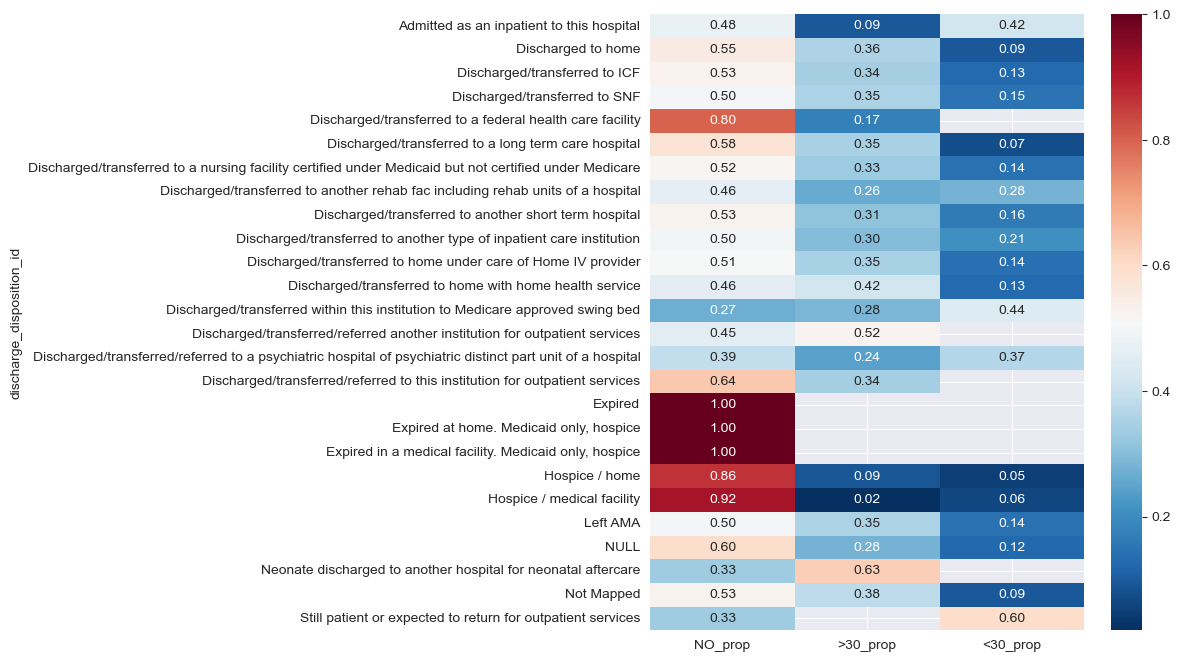

In [21]:
_ = xtab2(df, "discharge_disposition_id").drop("NO", ">30", "<30").to_pandas().set_index("discharge_disposition_id")
fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(_, cmap="RdBu_r", annot=True, fmt=".2f", ax=ax);

In [22]:
with pl.Config(tbl_rows=-1, fmt_str_lengths=200) as cfg:
    _ = "discharge_disposition_id"
    xtab2(df, _).filter(pl.col(_).str.contains("home") & ~pl.col(_).str.contains("^(Hospice|Expired).*$")).pipe(combine_readmit).pipe(recalc_props).pipe(display)

discharge_disposition_id,NO,YES,NO_prop,YES_prop
str,u32,u32,f64,f64
"""Discharged to home""",33115,27119,0.549773,0.450223
"""Discharged/transferred to home under care of Home IV provider""",55,53,0.509259,0.488438
"""Discharged/transferred to home with home health service""",5902,7000,0.457448,0.542532


In [23]:
with pl.Config(tbl_rows=-1, fmt_str_lengths=200) as cfg:
    _ = "discharge_disposition_id"
    xtab2(df, _).filter(pl.col(_).str.contains("rehab") & ~pl.col(_).str.contains("^(Hospice|Expired).*$")).pipe(combine_readmit).pipe(recalc_props).pipe(display)

discharge_disposition_id,NO,YES,NO_prop,YES_prop
str,u32,u32,f64,f64
"""Discharged/transferred to another rehab fac including rehab units of a hospital""",922,1071,0.462619,0.537256


In [24]:
with pl.Config(tbl_rows=-1, fmt_str_lengths=200) as cfg:
    _ = "discharge_disposition_id"
    xtab2(df, _).filter(pl.col(_).str.contains("nurs") & ~pl.col(_).str.contains("^(Hospice|Expired).*$")).pipe(combine_readmit).pipe(recalc_props).pipe(display)

discharge_disposition_id,NO,YES,NO_prop,YES_prop
str,u32,u32,f64,f64
"""Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare""",25,23,0.520833,0.474023


In [25]:
with pl.Config(tbl_rows=-1, fmt_str_lengths=200) as cfg:
    _ = "discharge_disposition_id"
    xtab2(df, _).filter(pl.col(_).str.contains("fac") & ~pl.col(_).str.contains("^(Hospice|Expired).*$")).pipe(combine_readmit).pipe(recalc_props).pipe(display)

discharge_disposition_id,NO,YES,NO_prop,YES_prop
str,u32,u32,f64,f64
"""Discharged/transferred to a federal health care facility""",4,null,1.0,null
"""Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare""",25,23,0.520833,0.474023
"""Discharged/transferred to another rehab fac including rehab units of a hospital""",922,1071,0.462619,0.537256


In [26]:
_ = "discharge_disposition_id"
xtab2(df, _).filter(pl.col(_).str.contains("fac") & ~pl.col(_).str.contains("^(Hospice|Expired).*$")).pipe(combine_readmit).sum().pipe(recalc_props)

discharge_disposition_id,NO,YES,NO_prop,YES_prop
str,u32,u32,f64,f64
null,951,1094,0.465037,0.534842


In [27]:
df.filter(pl.col("discharge_disposition_id").str.starts_with("Hospice")).height / df.height * 100

0.7576204233240964

In [28]:
df.filter(pl.col("discharge_disposition_id").str.starts_with("Expired")).height / df.height * 100

1.6233319576282843

### HbA1C

In [29]:
xtab2(df, "A1Cresult")

A1Cresult,NO,>30,<30,NO_prop,>30_prop,<30_prop
enum,u32,u32,u32,f64,f64,f64
"""None""",45322,29745,9681,0.534785,0.35098,0.114232
"""Norm""",2909,1599,482,0.582966,0.320403,0.096576
""">7""",2129,1300,383,0.558499,0.340978,0.100448
""">8""",4504,2901,811,0.548199,0.353068,0.098699


In [30]:
xtab2(df, "A1Cresult").drop("NO", ">30", "<30").rename(lambda x: x.replace("_prop", "")).sort("NO")

A1Cresult,NO,>30,<30
enum,f64,f64,f64
"""None""",0.534785,0.35098,0.114232
""">8""",0.548199,0.353068,0.098699
""">7""",0.558499,0.340978,0.100448
"""Norm""",0.582966,0.320403,0.096576


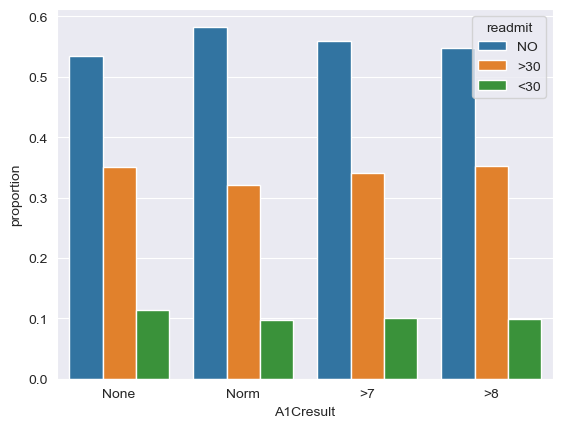

In [31]:
_ = xtab2(df, "A1Cresult").drop("NO", ">30", "<30").rename(lambda x: x.replace("_prop", "")).sort("NO").unpivot(index="A1Cresult", variable_name="readmit", value_name="proportion")
sns.barplot(_.to_pandas(), x="A1Cresult", y="proportion", hue="readmit");

In [32]:
(xtab2(df, "A1Cresult")
    .filter(pl.col("A1Cresult").ne("None"))
    .with_columns(pl.col("A1Cresult").gt("Norm").alias("abnormal"))
    .drop("A1Cresult")
    .group_by("abnormal")
    .sum()
    .pipe(recalc_props)
)

abnormal,NO,>30,<30,NO_prop,>30_prop,<30_prop
bool,u32,u32,u32,f64,f64,f64
false,2909,1599,482,0.582966,0.320403,0.096576
true,6633,4201,1194,0.551463,0.349252,0.099261


---

## Excursion: "Regular customers"

It has come to our attention that `patient_nbr` has duplicate values. Certain factors, such as demographics, are expected to be repeated, and might violate independence assumptions. At some point, we will need to make a decision on whether or not to retain unique patients, depending on the analyses planned. If yes, then the next question would be how. One way would be to retain the earliest record per patient, but the absence of temporal data would be an impediment. We could use `encounter_id` as a proxy for temporal order, assuming it is an auto-increment unique sequence.

Such removal of records will not be done for the initial EDA, at least for the purposes of Milestone 1, because the content of the EDA will be doubled, and we face land constraints.

Have a look these patients for now.

In [33]:
def calc_n_admissions(df: pl.DataFrame) -> pl.DataFrame:
    """
    Count number of encounters for each `patient_nbr`.
    Run separately if splitting.
    """
    vc = df["patient_nbr"].value_counts().rename({"count": "n_admissions"})
    df = df.drop("n_admissions", strict=False)
    df = df.join(vc, on="patient_nbr", how="left")
    lcols = ["encounter_id", "patient_nbr", "n_admissions"]
    df = df.select(*lcols, pl.exclude(lcols))
    return df


def nadm_xtab(df: pl.DataFrame, thr: int=20, row: str="patient_nbr", col: str="readmitted") -> pl.DataFrame:
    res = (df
        .pipe(calc_n_admissions)
        .filter(pl.col("n_admissions").gt(thr))
        .group_by(row, col).len()
        .sort(col, row)
        .pivot(index=row, on=col)
        .sort(pl.sum_horizontal(pl.exclude(row)), descending=True)
    )
    return res

In [34]:
(df
    .pipe(calc_n_admissions)
    .filter(pl.col("n_admissions").gt(1))
    .unique("patient_nbr").pipe(props, "n_admissions")
    .pipe(display)
)

n_admissions,proportion,cumulative
u32,f64,f64
2,0.622071,0.622071
3,0.198414,0.820485
4,0.084719,0.905205
5,0.042747,0.947952
6,0.020628,0.96858
…,…,…
21,0.00006,0.999583
22,0.000119,0.999702
23,0.000179,0.999881


In [35]:
nadm_xtab(df, thr=1)

patient_nbr,NO,>30,<30
i64,u32,u32,u32
88785891,null,17,23
43140906,1,5,22
1660293,1,11,11
23199021,null,16,7
88227540,null,11,12
…,…,…,…
112982949,null,null,2
113578128,null,null,2
138848009,null,null,2


In [36]:
nadm_xtab(df, thr=1).filter(pl.col("NO").gt(1))

patient_nbr,NO,>30,<30
i64,u32,u32,u32
85295430,2,5,2
92029617,2,2,1
92919915,2,2,1
102925989,2,2,1
108178776,2,2,1
…,…,…,…
60655932,2,null,null
88060779,2,null,null
101866896,2,null,null


#### Well, well, 44 patients who were "not readmitted" twice?

There is probably a window period beyond which someone will be considered a "new patient". We have not the facts to confirm or deny this. Just leave it at that, for now.

In [37]:
# Left as an exercise for the interested student:
# df2.pipe(calc_n_admissions).filter(pl.col("n_admissions").gt(1) & pl.col("readmitted").eq("NO")).filter(pl.col("patient_nbr").is_duplicated()).sort("patient_nbr")

#### Moving on

Compare against `number_inpatient`, sounds like they might be the same?

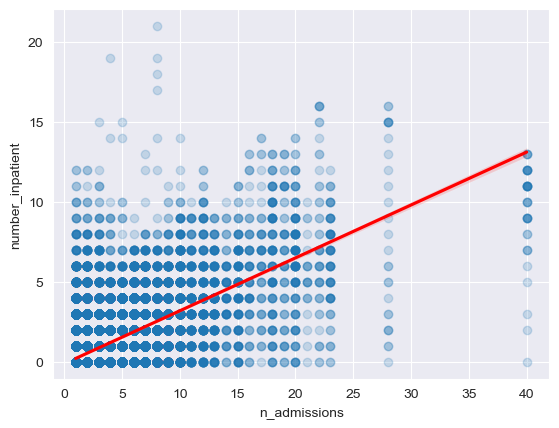

In [38]:
sns.regplot(df.pipe(calc_n_admissions).to_pandas(), x="n_admissions", y="number_inpatient", scatter_kws={"alpha": 0.2}, line_kws={"color": "r"});

In [39]:
df.pipe(calc_n_admissions).select("n_admissions", "number_inpatient").corr()

n_admissions,number_inpatient
f64,f64
1.0,0.639371
0.639371,1.0


In [40]:
spearmanr(df.pipe(calc_n_admissions).select("n_admissions", "number_inpatient"))

SignificanceResult(statistic=np.float64(0.5713889237107539), pvalue=np.float64(0.0))

#### Group by target

In [41]:
df.pipe(calc_n_admissions).sort(pl.col("encounter_id").cast(int)).unique("patient_nbr").pipe(xtab2, "n_admissions")

n_admissions,NO,>30,<30,NO_prop,>30_prop,<30_prop
u32,u32,u32,u32,f64,f64,f64
1,42701,9878,2166,0.779998,0.180434,0.039565
2,258,7648,2528,0.024727,0.732987,0.242267
3,24,2473,831,0.007212,0.743087,0.249643
4,2,1070,349,0.001407,0.75299,0.245471
5,null,520,197,null,0.725244,0.274478
…,…,…,…,…,…,…
21,null,1,null,null,1.0,null
22,null,1,1,null,0.5,0.4
23,null,2,1,null,0.666667,0.272727


In [42]:
(df
    .pipe(calc_n_admissions)
    .sort(pl.col("encounter_id").cast(int))
    .unique("patient_nbr")
    .group_by("readmitted")
    .agg(
        mean=pl.col("n_admissions").mean(),
        std=pl.col("n_admissions").std(),
        median=pl.col("n_admissions").median(),
        iqr=pl.col("n_admissions").quantile(0.75) - pl.col("n_admissions").quantile(0.25),
        skew=pl.col("n_admissions").skew(),
        kurtosis=pl.col("n_admissions").kurtosis(),
    )
)

readmitted,mean,std,median,iqr,skew,kurtosis
enum,f64,f64,f64,f64,f64,f64
"""NO""",1.007258,0.092745,1.0,0.0,14.462539,245.243811
""">30""",2.004317,1.491791,2.0,1.0,4.317885,44.060201
"""<30""",2.207691,1.614636,2.0,2.0,4.111972,33.408764


In [43]:
mannwhitneyu(df.pipe(calc_n_admissions).filter(pl.col("readmitted").eq("NO"))["n_admissions"], df.pipe(calc_n_admissions).filter(pl.col("readmitted").eq(">30"))["n_admissions"])

MannwhitneyuResult(statistic=np.float64(440248154.0), pvalue=np.float64(0.0))

In [44]:
mannwhitneyu(df.pipe(calc_n_admissions).filter(pl.col("readmitted").eq("NO"))["n_admissions"], df.pipe(calc_n_admissions).filter(pl.col("readmitted").eq("<30"))["n_admissions"])

MannwhitneyuResult(statistic=np.float64(107546041.0), pvalue=np.float64(0.0))

In [45]:
mannwhitneyu(df.pipe(calc_n_admissions).filter(pl.col("readmitted").eq(">30"))["n_admissions"], df.pipe(calc_n_admissions).filter(pl.col("readmitted").eq("<30"))["n_admissions"])

MannwhitneyuResult(statistic=np.float64(173790959.0), pvalue=np.float64(1.6412008129779882e-115))

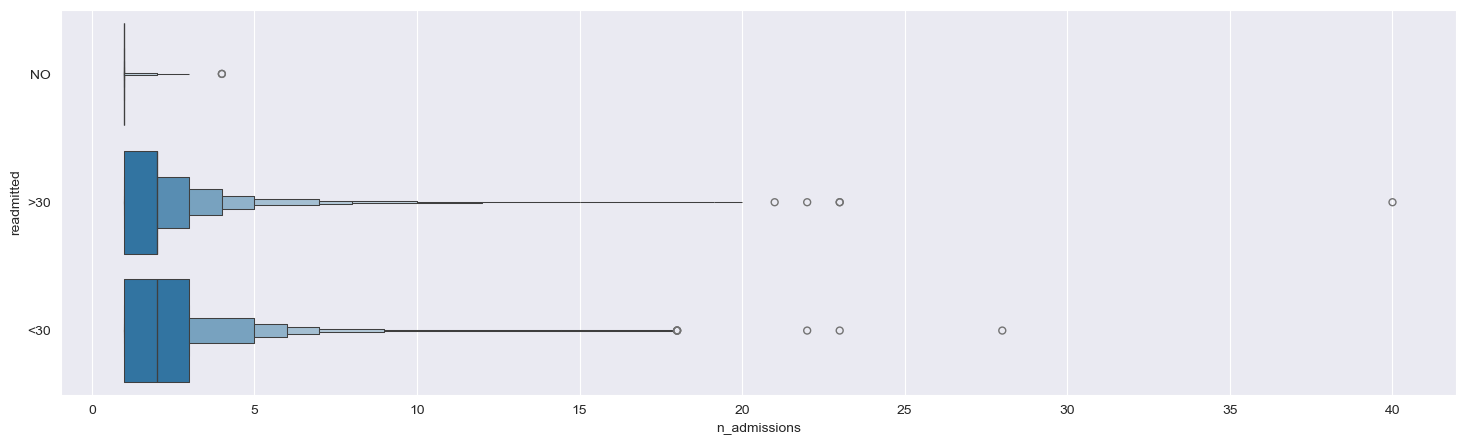

In [46]:
fig, ax = plt.subplots(figsize=(18, 5))
sns.boxenplot(df.pipe(calc_n_admissions).unique("patient_nbr").to_pandas(), x="n_admissions", y="readmitted", ax=ax);

---

## Explore low variance filter

... except we cannot calculate variance for nominal variables. 🫤

There are some options:
- Percentage of column occupied by the most frequent value
- Shannon entropy
- Gini impurity

Perhaps we go with Gini impurity for now, since the calculation is slightly simpler, and values are bounded between 0 (homogeneous/pure) and 1 (maximum impurity; 0.5 for 2 classes). Can also calculate percentage ocuupied by the most frequent value anyway to cross-reference.

In [47]:
def calc_gini_impurity(s: pl.Series) -> float:
    p = pl.col("proportion")
    vc = s.value_counts(normalize=True)
    vc = vc.with_columns(p.pow(2).alias("prop2"))
    return 1 - vc["prop2"].sum()


def drop_low_gini(df: pl.DataFrame, threshold: float=0.005, verbose: bool=True) -> pl.DataFrame:
    """
    Might have to try out different thresholds. Start off conservative at
    0.005, which for this dataset, would drop variables where the dominant
    value comprises 99.9% or more of the values.

    Could be more aggressive, possibly up to 0.09 (96.9%), which will
    conveniently drop `weight`, but retain `glimepiride` (0.097, 94.9%).
    """
    to_drop = {}
    for s in df:
        gini = calc_gini_impurity(s)
        if gini < threshold:
            vc = s.value_counts().sort(s.name)
            dct = dict(zip(vc[s.name], vc["count"]))
            to_drop[s.name] = {"Gini": gini, "ModePct": vc["count"].max() / df.height, "Values": dct}
    if verbose:
        n = len(to_drop)
        w1 = len(str(n))
        w2 = max(len(k) for k in to_drop)
        print(f"Dropping the following {n} variables with Gini below: {threshold}")
        for i, (k, v) in enumerate(to_drop.items(), start=1):
            print(f"  {i:0{w1}d}: {k:{w2}}, Gini = {v['Gini']:.6f}, ModePct = {v['ModePct']:.6f}, Values = {v['Values']}")
    df2 = df.drop(to_drop)
    return df2


def drop_manual(df: pl.DataFrame, verbose: bool=False) -> pl.DataFrame:
    df = df.filter(pl.col("gender").ne("Unknown/Invalid"))  # 3 rows.
    df = df.drop("payer_code")  # Probably irrelevant.
    df = drop_low_gini(df, threshold=0.09, verbose=verbose)
    return df

In [48]:
df.pipe(drop_manual, verbose=True);

Dropping the following 17 variables with Gini below: 0.09
  01: weight                  , Gini = 0.061554, ModePct = 0.968584, Values = {'?': 98566, '[0-25)': 48, '[25-50)': 97, '[50-75)': 897, '[75-100)': 1336, '[100-125)': 625, '[125-150)': 145, '[150-175)': 35, '[175-200)': 11, '>200': 3}
  02: repaglinide             , Gini = 0.029832, ModePct = 0.984877, Values = {'No': 100224, 'Down': 45, 'Steady': 1384, 'Up': 110}
  03: nateglinide             , Gini = 0.013726, ModePct = 0.993092, Values = {'No': 101060, 'Down': 11, 'Steady': 668, 'Up': 24}
  04: chlorpropamide          , Gini = 0.001689, ModePct = 0.999155, Values = {'No': 101677, 'Down': 1, 'Steady': 79, 'Up': 6}
  05: acetohexamide           , Gini = 0.000020, ModePct = 0.999990, Values = {'No': 101762, 'Steady': 1}
  06: tolbutamide             , Gini = 0.000452, ModePct = 0.999774, Values = {'No': 101740, 'Steady': 23}
  07: acarbose                , Gini = 0.006036, ModePct = 0.996973, Values = {'No': 101455, 'Down': 3, '

### That's about 1/3 of the columns dropped with a threshold of 0.09.

Was just looking for an excuse to drop `weight` since it has too many (96.7%) missing values. The rest had 98.5% or more of the column dominated by the mode.

In [49]:
pp(df.pipe(drop_manual).schema, width=200)

Schema([('encounter_id', Int64),
        ('patient_nbr', Int64),
        ('race', String),
        ('gender', String),
        ('age', Enum(categories=['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'])),
        ('admission_type_id', String),
        ('discharge_disposition_id', String),
        ('admission_source_id', String),
        ('time_in_hospital', Int64),
        ('medical_specialty', String),
        ('num_lab_procedures', Int64),
        ('num_procedures', Int64),
        ('num_medications', Int64),
        ('number_outpatient', Int64),
        ('number_emergency', Int64),
        ('number_inpatient', Int64),
        ('diag_1', String),
        ('diag_2', String),
        ('diag_3', String),
        ('number_diagnoses', Int64),
        ('max_glu_serum', Enum(categories=['None', 'Norm', '>200', '>300'])),
        ('A1Cresult', Enum(categories=['None', 'Norm', '>7', '>8'])),
        ('metformin', Enum(categories=['No

---

## Excursion: `age`

Strack _et al._ (2014) divided the age variable into 3 categories ([0, 30), [30, 60), [60, 100)) after observing _something_. They were using logistic regression to predict early readmittance, with might have preferred monotonicity. Binning into larger categories might have helped the points where trends were inverted. It seems non-trivial to reproduce that observation with simple proportions, but we try our best.

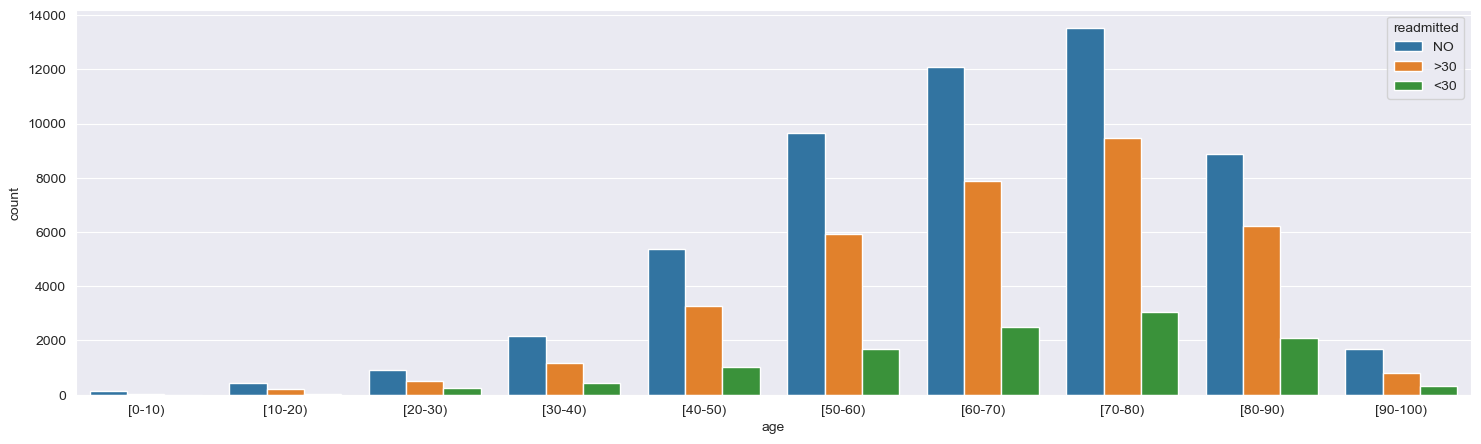

In [50]:
fig, ax = plt.subplots(figsize=(18, 5))
sns.countplot(df.to_pandas(), x="age", hue="readmitted", ax=ax);

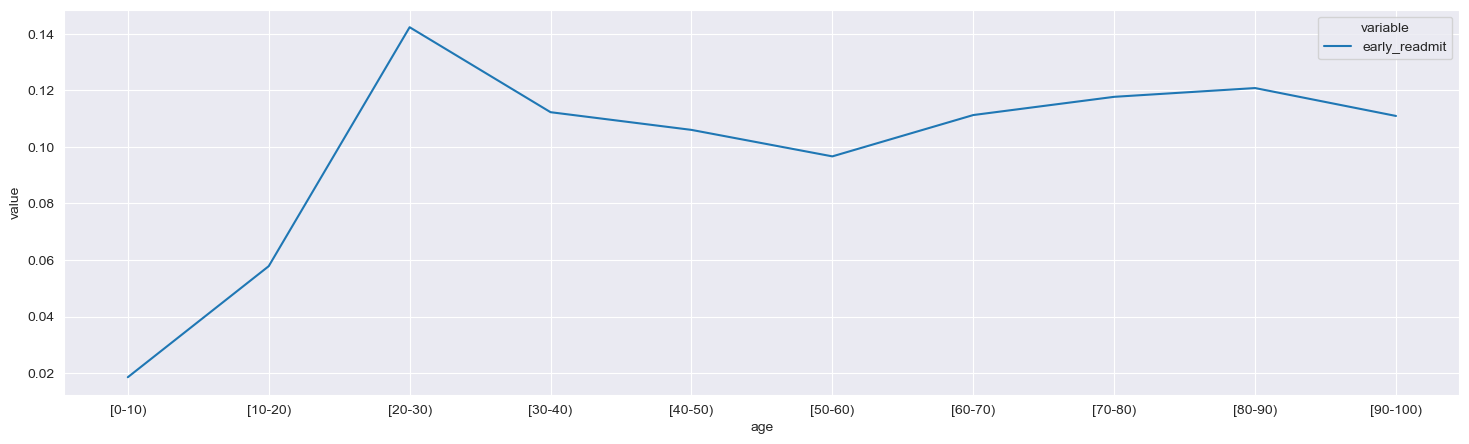

In [51]:
_ = (df
    .pipe(xtab2, "age")
    # .with_columns(pl.col(">30_prop").add(pl.col("<30_prop")).alias("all_readmit"))
    .rename({"<30_prop": "early_readmit"})
    .select("age", "early_readmit")
    .unpivot(index="age")
)
fig, ax = plt.subplots(figsize=(18, 5))
sns.lineplot(_.to_pandas(), x="age", y="value", hue="variable", ax=ax);

---

## Diagnoses (ICD-9 recoded): `diag_1`, `diag_2`, `diag_3`

>append a "b" after the names, in case we need the originals (might decide to recode a different way)

Even after categorizing into the broadest categories, there are still too many combinations. Can explore one-hot encoding (19-20 columns) for the secondary diagnoses.

In [52]:
df.group_by("diag_1b", "diag_2b", "diag_3b").len().sort("len", descending=True)

diag_1b,diag_2b,diag_3b,len
str,str,str,u32
"""Circulatory""","""Circulatory""","""Circulatory""",6746
"""Circulatory""","""Circulatory""","""Diabetes mellitus""",3399
"""Circulatory""","""Diabetes mellitus""","""Circulatory""",1577
"""Circulatory""","""Respiratory""","""Circulatory""",1364
"""Circulatory""","""Circulatory""","""Respiratory""",1280
…,…,…,…
"""Neoplasms""","""Blood""","""External Injury""",1
"""Musculoskeletal""","""Mental""","""Dermatology""",1
"""Dermatology""","""Musculoskeletal""","""Symptoms/Signs/Ill-defined""",1


In [53]:
def encode_secondary_diagnoses(df: pl.DataFrame) -> pl.DataFrame:
    uniq = df["diag_2b"].unique().sort()
    for k in uniq:
        df = df.with_columns(pl.lit(0).alias(k))
        df = df.with_columns(pl.when(pl.col("diag_2b").eq(k)).then(pl.col(k).add(1)).otherwise(k).alias(k))
        df = df.with_columns(pl.when(pl.col("diag_3b").eq(k)).then(pl.col(k).add(1)).otherwise(k).alias(k))
    return df


def _summ_secondary_diagnoses(df: pl.DataFrame) -> pl.DataFrame:
    uniq = df["diag_2b"].unique().sort().to_list()
    return df.select(uniq).sum()

In [54]:
with pl.Config(tbl_rows=-1) as cfg:
    (df["diag_1b"]
        .value_counts()
        .rename({"diag_1b": "category", "count": "primary_diag"})
        .join(df.pipe(encode_secondary_diagnoses).pipe(_summ_secondary_diagnoses).unpivot(variable_name="category", value_name="secondary_diag"),
              on="category")
        .sort(pl.sum_horizontal(pl.exclude("category")), descending=True)
        .pipe(display)
    )

category,primary_diag,secondary_diag
str,u32,i32
"""Circulatory""",30336,61283
"""Diabetes mellitus""",8757,29951
"""Respiratory""",10407,17025
"""Other Endocrine/Metabolic/Immu…",2702,17374
"""Genitourinary""",5078,14314
"""Symptoms/Signs/Ill-defined""",7636,9155
"""Digestive""",9208,7534
"""Injury/Poisoning""",6974,4374
"""Musculoskeletal""",4957,3679


#### Individual variables
- Circulatory dominates in terms of raw counts
- Followed by repiratory for primary or diabetes mellitus for secondary
- Diabetes mellitus kept as a standalone category

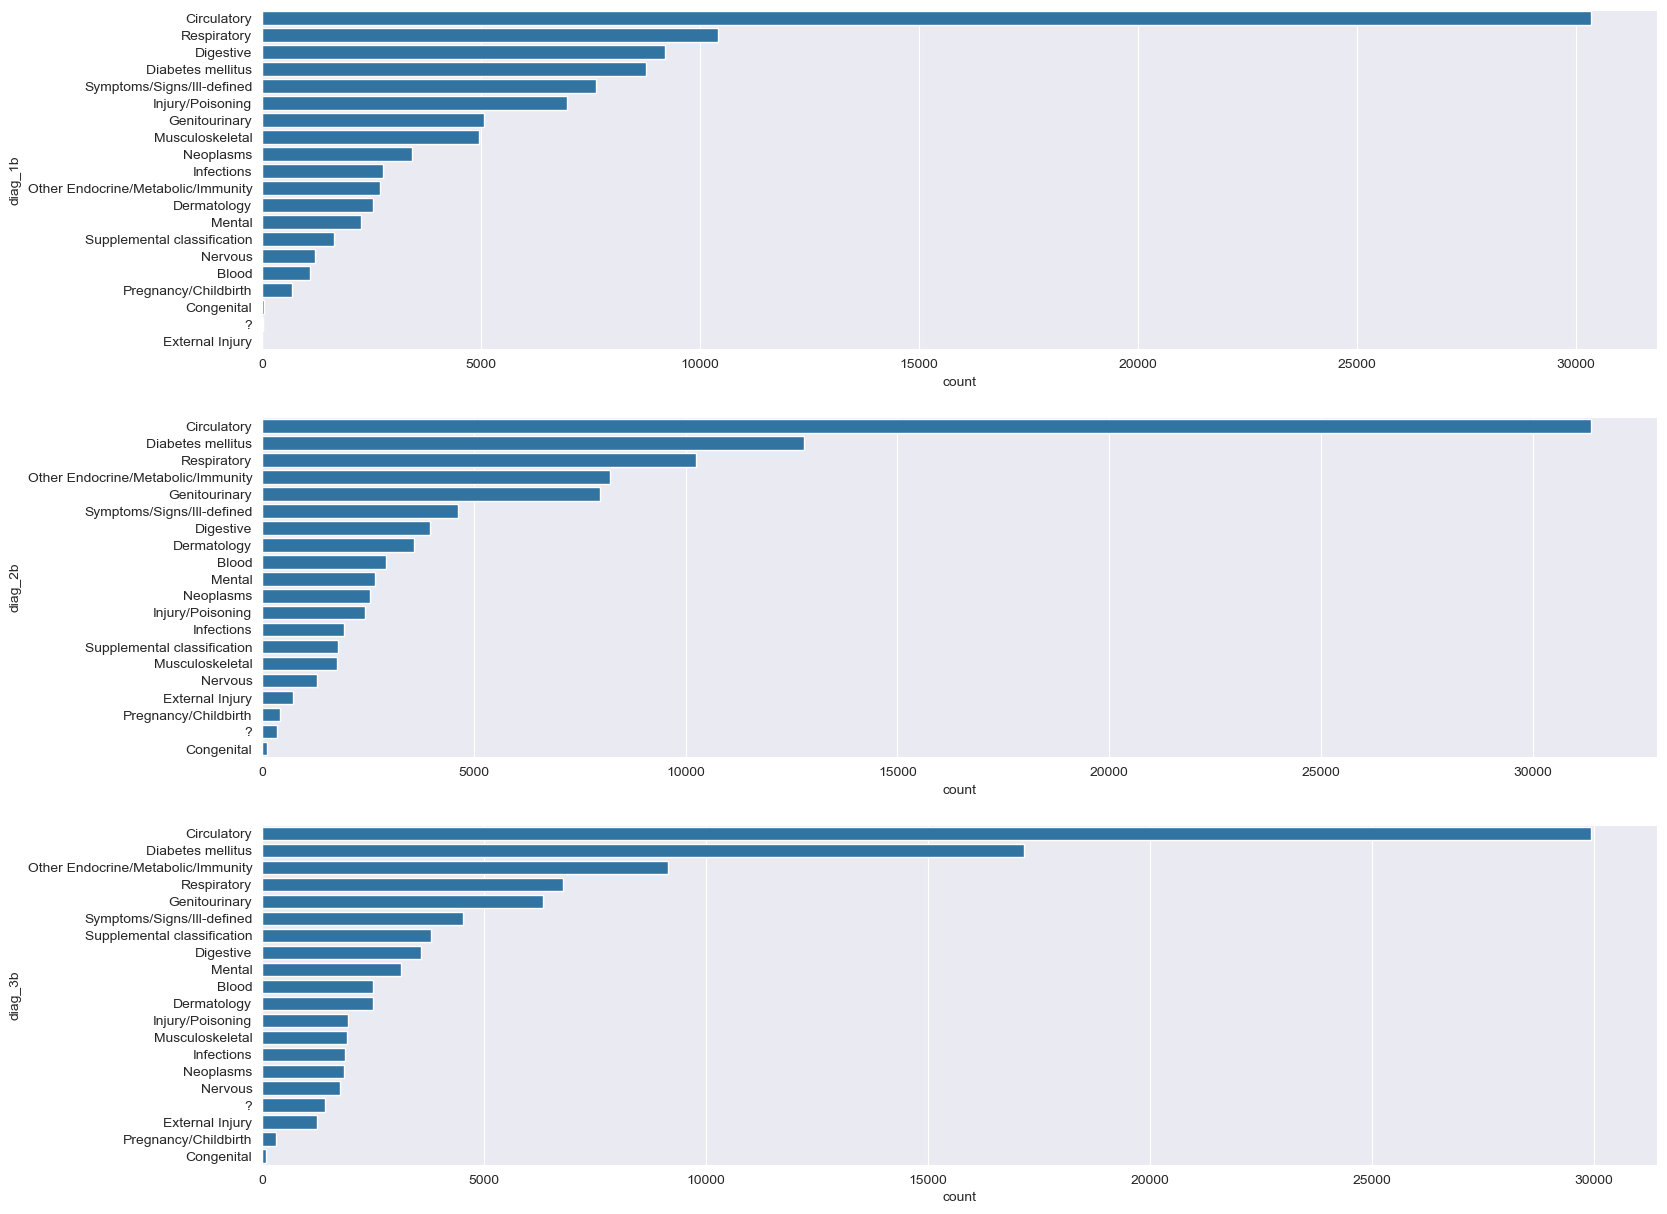

In [55]:
fig, axs = plt.subplots(nrows=3, figsize=(18, 5 * 3))
sns.barplot(df["diag_1b"].value_counts(sort=True).to_pandas(), y="diag_1b", x="count", ax=axs[0]);
sns.barplot(df["diag_2b"].value_counts(sort=True).to_pandas(), y="diag_2b", x="count", ax=axs[1]);
sns.barplot(df["diag_3b"].value_counts(sort=True).to_pandas(), y="diag_3b", x="count", ax=axs[2]);

#### Cross-tabulations against readmitted status

- Primary diagnoses with highest proportions of readmissions are "Blood", "Diabetes mellitus" (expected), "Injury/Supplemental classification", "Repiratory"

#### Adjust color palette to match CN's theme

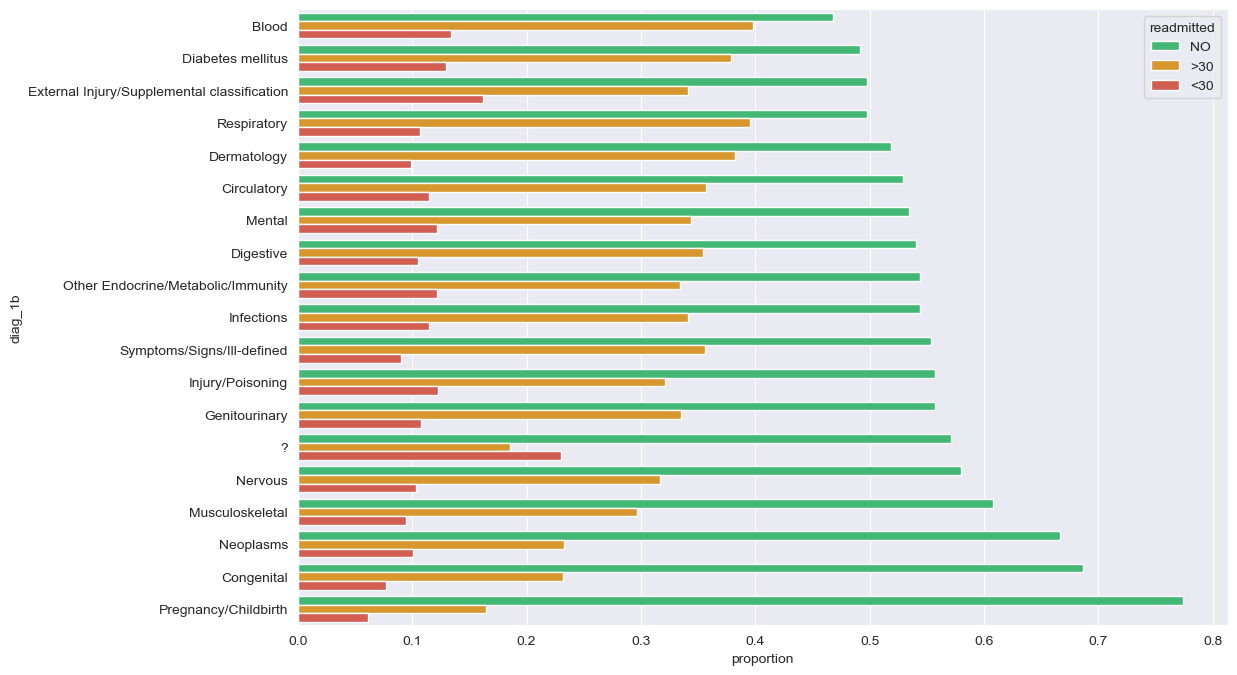

In [56]:
_f = lambda k: (df
    # Maintain old grouping for EDA.
    .with_columns(pl.col(k).replace({"External Injury": "External Injury/Supplemental classification",
                                     "Supplemental classification": "External Injury/Supplemental classification"}))
    .pipe(xtab2, k)
    .drop("NO", ">30", "<30")
    .rename(lambda x: x.replace("_prop", ""))
    .sort("NO")  # "NO" ascending would put the highest readmission rates on top.
    .unpivot(index=k, variable_name="readmitted", value_name="proportion")
)

colors = ["#2ecc71", "#f39c12", "#e74c3c"]

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(_f("diag_1b").to_pandas(), y="diag_1b", x="proportion", hue="readmitted", palette=sns.color_palette(colors), ax=ax);
if False:
    fig, axs = plt.subplots(nrows=3, figsize=(12, 8 * 3))
    sns.barplot(_f("diag_1b").to_pandas(), y="diag_1b", x="proportion", hue="readmitted", ax=axs[0]);
    sns.barplot(_f("diag_2b").to_pandas(), y="diag_2b", x="proportion", hue="readmitted", ax=axs[1]);
    sns.barplot(_f("diag_3b").to_pandas(), y="diag_3b", x="proportion", hue="readmitted", ax=axs[2]);

---

## `discharge_disposition_id`

We've re-did this and added a heatmap above. To recap, expired and discharged to hospice had low readmittance rates, 0% for expired, 11% for hospice. Expired is the only category with 0% readmittance.